<a href="https://colab.research.google.com/github/eng-Shahd-Mostafa/Vole-Machine-Simulator/blob/main/Medical_Image_Diagnosis_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Medical Image Diagnosis System
### Multi-Class Disease Classification with Explainable AI

This project aims to build an intelligent medical image diagnosis system that can automatically classify diseases from medical images such as **Chest X-rays** .

The system will explore both **classical machine learning techniques** and **deep learning approaches**, followed by **advanced AI methods** to improve diagnostic performance and interpretability.

---

## Project Goal
The goal is to develop a **robust, interpretable, and high-performance AI system** that can assist medical professionals in diagnosing diseases from medical imaging data.

In [ ]:
# Install required packages
!pip install opendatasets pandas

# Import Required Libraries
import os
import opendatasets as od
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
from PIL import Image

# Loading data

In [ ]:
# Download Chest X-Ray Pneumonia dataset from Kaggle
import opendatasets as od
dataset_url = "https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia"
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ibrahimmahdy178
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia


100%|██████████| 2.29G/2.29G [00:22<00:00, 112MB/s]


In [ ]:
# Define dataset paths
data_dir = "chest-xray-pneumonia/chest_xray"

train_dir = os.path.join(data_dir, "train")
test_dir = os.path.join(data_dir, "test")
val_dir = os.path.join(data_dir, "val")

# Quick Data Inspection


In [ ]:
# Check classes
print("Train Classes:", os.listdir(train_dir))

Train Classes: ['PNEUMONIA', 'NORMAL']


In [ ]:
# Count the number of images in each class.
for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    print(category, len(os.listdir(path)))

PNEUMONIA 3875
NORMAL 1341


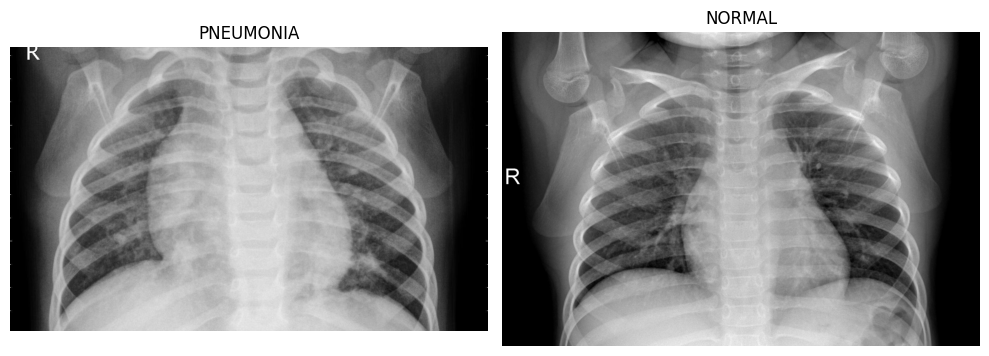

In [ ]:
# Display random sample images

pneumonia_path = os.path.join(train_dir, 'PNEUMONIA')
normal_path = os.path.join(train_dir, 'NORMAL')

# Randomly select one image from each class
pneumonia_img_name = random.choice(os.listdir(pneumonia_path))
normal_img_name = random.choice(os.listdir(normal_path))

# Read and convert images to RGB
pneumonia_img = cv2.cvtColor(cv2.imread(os.path.join(pneumonia_path, pneumonia_img_name)), cv2.COLOR_BGR2RGB)
normal_img = cv2.cvtColor(cv2.imread(os.path.join(normal_path, normal_img_name)), cv2.COLOR_BGR2RGB)

# Plot images side by side
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(pneumonia_img)
plt.title('PNEUMONIA')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(normal_img)
plt.title('NORMAL')
plt.axis('off')
plt.tight_layout()
plt.show()


# Data Cleaning & DataFrame Preparation



In [ ]:
# Collect and Clean Image Data
data_records = []
corrupted_images = []

dataset_splits = ['train', 'test', 'val']

for split in dataset_splits:
    split_dir = os.path.join(data_dir, split)
    if not os.path.exists(split_dir):
        print(f"Directory not found: {split_dir}")
        continue

    for category in os.listdir(split_dir):
        category_dir = os.path.join(split_dir, category)
        if not os.path.isdir(category_dir):
            continue

        for img_name in os.listdir(category_dir):
            image_path = os.path.join(category_dir, img_name)
            try:
                # Verify that the image is valid
                with Image.open(image_path) as img:
                    img.verify()
                # Add valid image to records
                data_records.append({
                    'image_path': image_path,
                    'label': category,
                    'split': split
                })
            except Exception as e:
                # Keep track of corrupted images
                corrupted_images.append(image_path)

# Save corrupted images for review
if corrupted_images:
    corrupted_df = pd.DataFrame(corrupted_images, columns=['image_path'])
    corrupted_df.to_csv('corrupted_images.csv', index=False)
    print(f"Saved {len(corrupted_images)} corrupted images to 'corrupted_images.csv'.")


In [ ]:
# Create DataFrame

df = pd.DataFrame(data_records)
print(f"Total images processed: {len(data_records) + len(corrupted_images)}")
print(f"Number of valid images: {len(data_records)}")
print(f"Number of corrupted images: {len(corrupted_images)}")

Total images processed: 5856
Number of valid images: 5856
Number of corrupted images: 0


In [ ]:
# Remove duplicate image entries

duplicates = df[df.duplicated(subset=['image_path'])]
if not duplicates.empty:
    df.drop_duplicates(subset=['image_path'], inplace=True)
    print(f"Removed {len(duplicates)} duplicate entries.")
else:
    print("No duplicate image entries found.")

No duplicate image entries found.


In [ ]:
# Preprocessing function: Convert RGB + Resize

IMG_SIZE = 224

def preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        return np.array(img)
    except Exception as e:
        print(f"Error processing image {image_path}: {e}")
        return None

In [ ]:
# Preprocess images and split into train/test/val arrays

X_train, y_train = [], []
X_test, y_test = [], []
X_val, y_val = [], []

for idx, row in df.iterrows():
    processed_image = preprocess_image(row['image_path'])
    if processed_image is not None:
        if row['split'] == 'train':
            X_train.append(processed_image)
            y_train.append(row['label'])
        elif row['split'] == 'test':
            X_test.append(processed_image)
            y_test.append(row['label'])
        elif row['split'] == 'val':
            X_val.append(processed_image)
            y_val.append(row['label'])

print(f"Processed {len(X_train)} training images.")
print(f"Processed {len(X_test)} testing images.")
print(f"Processed {len(X_val)} validation images.")

Processed 5216 training images.
Processed 624 testing images.
Processed 16 validation images.


In [ ]:
#  DataFrame inspection

print("\nDataFrame head after cleaning:")
print(df.head())

print("\nDataFrame info:")
df.info()

print("\nDataFrame descriptive statistics:")
print(df.describe(include='all'))

# Save Cleaned DataFrame
df.to_csv("cleaned_chest_xray_df.csv", index=False)
print("\nCleaned DataFrame saved to 'cleaned_chest_xray_df.csv'")